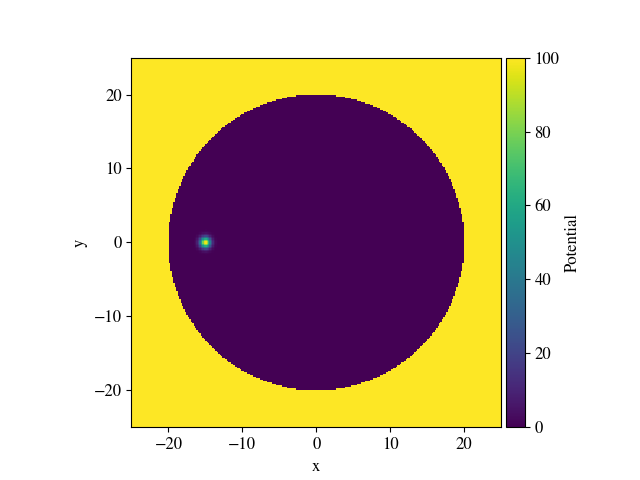

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_eigenvector
from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT
from BECs.ufuncs import gaussian2D



%matplotlib widget

### ----------------------
# Setting up the potential

s = 50 # simulation box size
resolution = (256,256) # Simulation box resolution

box_trap = Potential( # For now, we only need a simple Potential object
    unitvecs=[[s, 0], [0, s]], # A square box of side s
    resolution=resolution,
    v0 = 200
)

box_trap.circle(
    (0,0),
    20
)

def chopstick(x0, y0, amp):
    return gaussian2D(box_trap.x, box_trap.y, x0, y0, 0.5, 0.5, amp)


x0 = -15
y0 = 0
amp = 50

box_trap.add(chopstick(x0, y0, amp))
box_trap.add(chopstick(x0, y0, amp))

box_trap.plot(vmax = amp * 2)
plt.show()

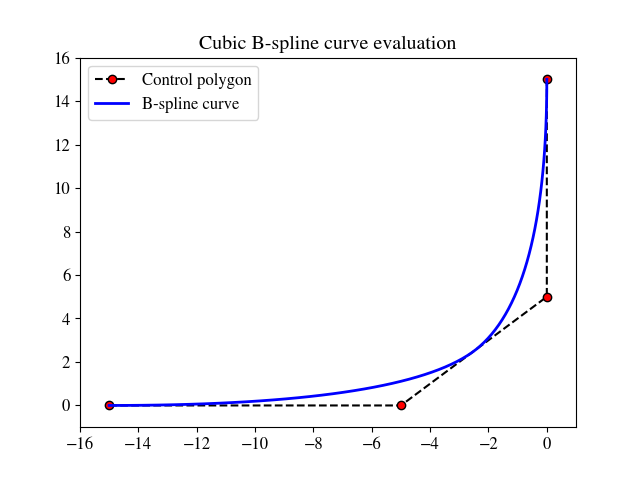

In [20]:

import numpy as np
from scipy import interpolate

import matplotlib.pyplot as plt


ctr =np.array([[x0, y0], [-5,0], [0, 5], [0, 15]])
x=ctr[:,0]
y=ctr[:,1]

# uncomment both lines for a closed curve
#x=np.append(x,[x[0]])  
#y=np.append(y,[y[0]])

l=len(x)  

t=np.linspace(0,1,l-1,endpoint=True)
t=np.append([0,0],t)
t=np.append(t,[1,1])

tck=[t,[x,y],2]
u3=np.linspace(0,1,(max(l*2,70)),endpoint=True)
out = interpolate.splev(u3,tck)

plt.close('all')
plt.plot(x,y,'k--',label='Control polygon',marker='o',markerfacecolor='red')
#plt.plot(x,y,'ro',label='Control points only')
plt.plot(out[0],out[1],'b',linewidth=2.0,label='B-spline curve')
plt.legend(loc='best')
plt.axis([min(x)-1, max(x)+1, min(y)-1, max(y)+1])
plt.title('Cubic B-spline curve evaluation')
plt.show()